# ETS MARL — Episode Viewer

Inspect **one** episode at the finest grain available. Use this notebook to:

- Load a configuration (and optionally a trained checkpoint, e.g. the final episode of a long run).
- Roll out a single deterministic episode and capture every per-year log + per-company snapshot.
- Switch between a **market perspective** (cap / TNAC / MSR / clearing prices / volumes / defaults) and a **company perspective** (budgets, transactions, investments, compliance, rewards).
- Drill into a single year (`INSPECT_YEAR`) or a single company across the whole episode (`INSPECT_AGENT`).

Everything below is plain pandas / matplotlib; nothing is hidden in helper modules. Tweak the controls in the next cell, run all, and use the section headers as a table of contents.


In [ ]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")


All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Controls

Set the inputs for the rollout. The notebook is fully self-contained; no external debug script required.

- `CONFIG_PATH` - YAML config to use. Defaults to `configs/default.yaml`.
- `SEED` - RNG seed for reset() + policies.
- `CHECKPOINT_DIR` - directory containing `agent_<i>_best.pt` files, or a compressed checkpoint archive such as `checkpoints_default_s1729.tar.xz`. Set to `None` to use untrained agents.
- `CHECKPOINT_PATTERN` - filename pattern to load from the checkpoint source, e.g. `agent_{i}_best.pt` or `agent_{i}_ep119500.pt`.
- `ALLOW_MISSING_CHECKPOINTS` - keep `False` for run analysis; missing checkpoints then fail loudly instead of silently falling back to random initialisation.
- `N_BOTS_OVERRIDE` / `N_LEARNING_OVERRIDE` - set to `None` to use what's in the config, or override (e.g. `N_BOTS_OVERRIDE=0` to remove bots from the view).
- `DETERMINISTIC` - if `True`, policies act on the mean (no exploration noise).
- `INSPECT_YEAR` - 1-based year to deep-dive (set to `None` to deep-dive the last simulated year).
- `INSPECT_AGENT` - agent index for the single-company walk-through.
- `EXPORT_DIR` - where to write optional CSV exports and small notebook caches.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

# --- locate project root --------------------------------------------------
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "configs").exists() and (parent / "src").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- USER CONTROLS --------------------------------------------------------
CONFIG_PATH         = PROJECT_ROOT / "configs" / "default.yaml"
SEED                = 1729

# Set to a checkpoint directory OR compressed checkpoint archive to load a
# trained policy. Leave None to use freshly initialised PPO networks.
CHECKPOINT_DIR      = PROJECT_ROOT / "results" / "sweeps" / "default" / "checkpoints_default_s1729.tar.xz"
CHECKPOINT_PATTERN  = "agent_{i}_best.pt"  # e.g. "agent_{i}_ep119500.pt" for a retained episode checkpoint
ALLOW_MISSING_CHECKPOINTS = False

# Override participant counts (None = use config values).
N_LEARNING_OVERRIDE = None
N_BOTS_OVERRIDE     = None

DETERMINISTIC       = True

# Year/agent of interest. INSPECT_YEAR is 1-based; None = last simulated year.
INSPECT_YEAR        = None
INSPECT_AGENT       = 0

# Export/cache controls.
EXPORT_CSV          = False
EXPORT_DIR          = PROJECT_ROOT / "results" / "episode_viewer"
CHECKPOINT_CACHE_DIR = EXPORT_DIR / "checkpoint_cache"

# Display controls (how wide to print pandas tables).
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


## 2. Load config & build environment

Loads the YAML, applies optional overrides, builds an `ETSEnvironment`, and (if `CHECKPOINT_DIR` is set) loads PPO actors via the same `build_agents` factory used by `scripts/train.py` and `scripts/evaluate.py`.


In [3]:
from contextlib import ExitStack, contextmanager
import importlib
import os
import shutil
import tarfile

from src.environment.ets_environment import ETSEnvironment
from scripts.train import build_agents
from src.utils.run_data import checkpoint_archive_suffixes

with open(CONFIG_PATH, encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)

# Apply optional overrides BEFORE constructing the environment so all
# downstream sizing (obs/action dims, bot arrays, etc.) is consistent.
if N_LEARNING_OVERRIDE is not None:
    cfg["companies"]["n_agents"] = int(N_LEARNING_OVERRIDE)
if N_BOTS_OVERRIDE is not None:
    cfg["companies"]["n_bot_agents"] = int(N_BOTS_OVERRIDE)

env = ETSEnvironment(cfg, seed=SEED)
N_LEARNING = int(cfg["companies"]["n_agents"])
N_BOTS     = int(cfg["companies"]["n_bot_agents"])
N_TOTAL    = env.n_total
N_YEARS    = int(cfg["simulation"]["n_years"])
TECH_NAMES = list(cfg["technologies"]["names"])
BUILDABLE_TECH_NAMES = [TECH_NAMES[i] for i, b in enumerate(cfg["technologies"]["is_buildable"]) if b]


def _checkpoint_archive_stem(path: Path) -> str:
    name = path.name
    for suffix in checkpoint_archive_suffixes():
        if name.lower().endswith(suffix):
            return name[: -len(suffix)]
    return path.stem


@contextmanager
def _open_checkpoint_archive(path: Path):
    archive_path = os.fspath(path)
    lower = archive_path.lower()
    with ExitStack() as stack:
        if lower.endswith(".tar.zst"):
            zstandard = importlib.import_module("zstandard")
            raw = stack.enter_context(open(archive_path, "rb"))
            reader = stack.enter_context(zstandard.ZstdDecompressor().stream_reader(raw))
            tar = stack.enter_context(tarfile.open(fileobj=reader, mode="r|"))
        elif lower.endswith(".tar.gz"):
            tar = stack.enter_context(tarfile.open(archive_path, mode="r:gz"))
        elif lower.endswith(".tar.xz"):
            tar = stack.enter_context(tarfile.open(archive_path, mode="r:xz"))
        else:
            raise ValueError(f"Unsupported checkpoint archive type: {path}")
        yield tar


def _resolve_checkpoint_dir(checkpoint_dir, pattern: str, n_agents: int) -> tuple[Path, Path | None]:
    ckpt_root = Path(checkpoint_dir)
    if not ckpt_root.is_absolute():
        ckpt_root = PROJECT_ROOT / ckpt_root
    if not ckpt_root.exists():
        raise FileNotFoundError(f"CHECKPOINT_DIR not found: {ckpt_root}")

    archive_suffixes = checkpoint_archive_suffixes()
    if ckpt_root.is_file() and str(ckpt_root).lower().endswith(archive_suffixes):
        target_dir = CHECKPOINT_CACHE_DIR / _checkpoint_archive_stem(ckpt_root)
        target_dir.mkdir(parents=True, exist_ok=True)
        expected = {pattern.format(i=i) for i in range(n_agents)}
        if not all((target_dir / name).exists() for name in expected):
            found = set()
            with _open_checkpoint_archive(ckpt_root) as tar:
                for member in tar:
                    base = Path(member.name).name
                    if not member.isfile() or base not in expected:
                        continue
                    src = tar.extractfile(member)
                    if src is None:
                        continue
                    with src, open(target_dir / base, "wb") as dst:
                        shutil.copyfileobj(src, dst)
                    found.add(base)
                    if found == expected:
                        break
            still_missing = sorted(name for name in expected if not (target_dir / name).exists())
            if still_missing:
                raise FileNotFoundError(
                    f"Checkpoint archive {ckpt_root} did not contain expected files: {still_missing}"
                )
        return target_dir, ckpt_root

    if ckpt_root.is_file():
        raise NotADirectoryError(
            f"CHECKPOINT_DIR is a file but not a supported checkpoint archive: {ckpt_root}"
        )
    if not ckpt_root.is_dir():
        raise NotADirectoryError(f"CHECKPOINT_DIR is not a directory: {ckpt_root}")
    return ckpt_root, None


# Build PPO agents using the same factory as scripts/train.py and scripts/evaluate.py.
# When CHECKPOINT_DIR is supplied we load the trained weights; otherwise the agents
# stay at their random initialisation, which gives a clean "untrained baseline" view
# of the environment. Bots, when present, are driven by the env's own heuristic
# policy inside step_auction / step_secondary, so this notebook only needs to
# produce actions for the LEARNING agents.
agents = build_agents(env, cfg, SEED)
policy_mode = "untrained_ppo"
checkpoint_source = None
checkpoint_root = None
loaded_agents = []
missing = []
if CHECKPOINT_DIR is not None:
    checkpoint_root, checkpoint_source = _resolve_checkpoint_dir(
        CHECKPOINT_DIR, CHECKPOINT_PATTERN, N_LEARNING
    )
    for i, ag in enumerate(agents):
        ckpt_path = checkpoint_root / CHECKPOINT_PATTERN.format(i=i)
        if ckpt_path.exists():
            ag.load(str(ckpt_path))
            loaded_agents.append(i)
        else:
            missing.append(i)
    if missing:
        msg = f"Missing checkpoints for agents {missing} in {checkpoint_root}."
        if ALLOW_MISSING_CHECKPOINTS:
            print(f"WARNING: {msg} They keep random init.")
        else:
            raise FileNotFoundError(msg)
    policy_mode = f"checkpoint:{checkpoint_root.name}"

print(f"Project root        : {PROJECT_ROOT}")
print(f"Config              : {CONFIG_PATH}")
print(f"Years simulated     : {N_YEARS}")
print(f"Learning agents     : {N_LEARNING}    Bots: {N_BOTS}    Total: {N_TOTAL}")
print(f"Policy mode         : {policy_mode}")
if checkpoint_source is not None:
    print(f"Checkpoint archive  : {checkpoint_source}")
if checkpoint_root is not None:
    print(f"Checkpoint directory: {checkpoint_root}")
    print(f"Checkpoints loaded  : {len(loaded_agents)}/{N_LEARNING} agents {loaded_agents}")
print(f"Deterministic actions: {DETERMINISTIC}")


Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
Project root        : c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction
Config              : c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\default.yaml
Years simulated     : 12
Learning agents     : 8    Bots: 0    Total: 8
Policy mode         : checkpoint:checkpoints_default_s1729
Checkpoint archive  : c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\sweeps\default\checkpoints_default_s1729.tar.xz
Checkpoint directory: c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results\episode_viewer\checkpoint_cache\checkpoints_default_s1729
Checkpoints loaded  : 8/8 agents [0, 1, 2, 3, 4, 5, 6, 7]
Deterministic actions: True


## 3. Roll out one episode and capture everything

Helper functions:

- `participant_label(i)` — `A0..A{N_LEARNING-1}` for learners, `B0..B{N_BOTS-1}` for bots.
- `select_phase1/2_actions(obs)` — drives the **learning** agents using the actors built above (trained when a checkpoint was loaded; random init otherwise). Bot actions are produced inside the environment\'s `step_*` methods.

Each year we record:

1. The **pre-step snapshot** (annual budget, budget already spent, treasury, loan, bank, mix, queue size).
2. The **raw actions** (auction 6-D, secondary 2-D) — what the policy actually emitted, before any environment-side clipping/gating.
3. The full **`year_log`** dict returned by `step_secondary` (this is the same dict used by `train.py` for diagnostics).
4. The **post-step snapshot** of the same per-company state.


In [4]:
from tqdm.auto import tqdm


def participant_label(i: int) -> str:
    return f"A{i}" if i < N_LEARNING else f"B{i - N_LEARNING}"

def participant_kind(i: int) -> str:
    return "learning" if i < N_LEARNING else "bot"

def select_phase1_actions(obs1):
    actions = np.zeros((N_LEARNING, 6), dtype=np.float32)
    for i in range(N_LEARNING):
        a, _, _ = agents[i].select_auction_action(obs1[i], deterministic=DETERMINISTIC)
        actions[i] = a
    return actions

def select_phase2_actions(obs2):
    actions = np.zeros((N_LEARNING, 2), dtype=np.float32)
    for i in range(N_LEARNING):
        a, _, _ = agents[i].select_secondary_action(obs2[i], deterministic=DETERMINISTIC)
        actions[i] = a
    return actions

def snapshot_companies():
    rows = []
    for i, c in enumerate(env.companies):
        rows.append({
            "agent": i,
            "label": participant_label(i),
            "kind": participant_kind(i),
            "annual_budget": float(c.annual_budget),
            "budget_spent": float(c.budget_spent_this_year),
            "budget_avail": float(c.annual_budget - c.budget_spent_this_year),
            "treasury": float(c._treasury_reserve),
            "treasury_drawn": float(c._treasury_drawn_this_year),
            "loan_outstanding": float(c._loan_outstanding),
            "bank_holdings": float(env.holdings[i]),
            "carry_forward": float(c._carry_forward),
            "green_frac": float(c.green_frac),
            "fossil_frac": float(c.fossil_frac),
            "queue_size": int(len(c._construction_queue)),
            **{f"mix_{TECH_NAMES[t]}": float(c.mix[t]) for t in range(len(TECH_NAMES))},
        })
    return pd.DataFrame(rows)

# ---- Reset & roll out -----------------------------------------------------
obs1, _ = env.reset(seed=SEED)
year_logs        = []   # one dict per simulated year
pre_snapshots    = []   # company snapshots BEFORE step_auction
post_snapshots   = []   # company snapshots AFTER step_secondary
raw_phase1_acts  = []   # raw learning-agent phase-1 actions
raw_phase2_acts  = []   # raw learning-agent phase-2 actions
total_rewards    = np.zeros(N_LEARNING)

for year in tqdm(range(N_YEARS), desc='Rolling out episode', unit='year', leave=True):
    pre_snapshots.append(snapshot_companies().assign(year=year + 1))

    a1 = select_phase1_actions(obs1)
    raw_phase1_acts.append(a1.copy())
    obs2, _ = env.step_auction(a1)

    a2 = select_phase2_actions(obs2)
    raw_phase2_acts.append(a2.copy())
    obs1, rewards, terminated, _, info = env.step_secondary(a2)
    total_rewards += rewards

    log = info["year_log"]
    log["_year_1based"] = year + 1
    year_logs.append(log)
    post_snapshots.append(snapshot_companies().assign(year=year + 1))

    if terminated:
        break

YEARS_DONE = len(year_logs)
print(f"Simulated {YEARS_DONE}/{N_YEARS} years.")
print("Total learning-agent rewards (raw):")
display(pd.DataFrame({
    "agent": [participant_label(i) for i in range(N_LEARNING)],
    "total_reward": total_rewards,
}))

# Resolve INSPECT_YEAR / INSPECT_AGENT now that we know YEARS_DONE.
if INSPECT_YEAR is None:
    INSPECT_YEAR = YEARS_DONE
if not (1 <= INSPECT_YEAR <= YEARS_DONE):
    raise ValueError(f"INSPECT_YEAR must be in [1, {YEARS_DONE}], got {INSPECT_YEAR}.")
if not (0 <= INSPECT_AGENT < N_TOTAL):
    raise ValueError(f"INSPECT_AGENT must be in [0, {N_TOTAL - 1}], got {INSPECT_AGENT}.")
print(f"Year deep-dive: INSPECT_YEAR={INSPECT_YEAR}    Single-company walk-through: INSPECT_AGENT={INSPECT_AGENT} ({participant_label(INSPECT_AGENT)})")


[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.90, A2=1.57, A3=1.66, A4=1.57, A5=1.00, A6=1.22, A7=0.80, A8=0.87
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.


Rolling out episode:   0%|          | 0/12 [00:00<?, ?year/s]

Simulated 12/12 years.
Total learning-agent rewards (raw):


,agent,total_reward
0,A0,-9.3929
1,A1,-5.7725
2,A2,-16.9395
3,A3,5.1084
4,A4,1.6855
5,A5,10.6896
6,A6,18.6549
7,A7,3.6897


Year deep-dive: INSPECT_YEAR=12    Single-company walk-through: INSPECT_AGENT=0 (A0)


## 4. Episode summary — Market perspective

One row per simulated year. Use this to spot regime shifts (price hitting reserve, MSR firing, defaults, etc.) at a glance, before drilling into a specific year.


In [5]:
def _g(d, key, default=np.nan):
    v = d.get(key, default)
    return v if v is not None else default

market_rows = []
for log in year_logs:
    stats = log.get("auction_stats", {}) or {}
    market_rows.append({
        "year"                 : log["_year_1based"],
        "cap_mt"               : float(_g(log, "cap")),
        "tnac_mt"              : float(_g(log, "tnac")),
        "msr_reserve_mt"       : float(_g(log, "msr_reserve", 0.0)),
        "msr_withhold_mt"      : float(_g(log, "msr_withhold_this_year", 0.0)),
        "msr_release_mt"       : float(_g(log, "msr_release_this_year", 0.0)),
        "msr_total_cancelled"  : float(_g(log, "msr_total_cancelled", 0.0)),
        "auction_volume_mt"    : float(_g(log, "auction_volume")),
        "rollover_in_mt"       : float(_g(log, "unsold_rollover_in", 0.0)),
        "rollover_out_mt"      : float(_g(log, "unsold_rollover_out", 0.0)),
        "default_rolled_in_mt" : float(_g(log, "defaulted_volume_rolled_in", 0.0)),
        "reserve_eur"          : float(_g(log, "effective_reserve")),
        "anchor_eur"           : float(_g(log, "anchor_t")) if log.get("anchor_t") is not None else np.nan,
        "auction_clearing_eur" : float(_g(log, "clearing_price")),
        "secondary_clearing_eur": float(_g(log, "secondary_clearing")),
        "auction_demand_mt"    : float(stats.get("total_demand", np.nan)),
        "auction_allocated_mt" : float(stats.get("total_allocated", np.nan)),
        "auction_failed"       : bool(stats.get("auction_failed", False)),
        "auction_defaults"     : int(stats.get("defaults", 0)),
        "secondary_volume_mt"  : float(_g(log, "secondary_volume", 0.0)),
        "phantom_active"       : bool(_g(log, "phantom_active", False)),
        "phantom_bid_eur"      : float(_g(log, "phantom_bid_price", np.nan)),
        "phantom_bid_qty_mt"   : float(_g(log, "phantom_bid_qty", np.nan)),
        "emissions_total_mt"   : float(np.sum(_g(log, "emissions", []))),
        "shortfalls_total_mt"  : float(np.sum(_g(log, "shortfalls", []))),
        "penalties_total_meur" : float(np.sum(_g(log, "penalties", []))),
        "invest_costs_total_meur": float(np.sum(_g(log, "invest_costs", []))),
        "trade_costs_total_meur" : float(np.sum(_g(log, "trade_costs", []))),
        "auction_payments_total_meur": float(np.sum(_g(log, "payments", []))),
        "inflation_factor"     : float(_g(log, "inflation_factor", 1.0)),
        "mean_reward_learning" : float(np.mean(_g(log, "rewards", [np.nan])[:N_LEARNING])) if log.get("rewards") else np.nan,
    })
market_summary_df = pd.DataFrame(market_rows)
print("Market summary (one row per year)")
display(market_summary_df)


Market summary (one row per year)


,year,cap_mt,tnac_mt,msr_reserve_mt,msr_withhold_mt,msr_release_mt,msr_total_cancelled,auction_volume_mt,rollover_in_mt,rollover_out_mt,default_rolled_in_mt,reserve_eur,anchor_eur,auction_clearing_eur,secondary_clearing_eur,auction_demand_mt,auction_allocated_mt,auction_failed,auction_defaults,secondary_volume_mt,phantom_active,phantom_bid_eur,phantom_bid_qty_mt,emissions_total_mt,shortfalls_total_mt,penalties_total_meur,invest_costs_total_meur,trade_costs_total_meur,auction_payments_total_meur,inflation_factor,mean_reward_learning
0,1,22.8129,10.5872,5.6616,0.0000,0.0000,4.8072,22.8129,0.0000,0.0000,0.0000,45.0000,67.2000,45.0000,144.8023,26.4335,22.8129,False,0,3.7852,False,0.0000,0.0000,20.0531,0.1874,25.9963,427.7742,3.7852,"1,026.5805",1.0000,-0.0748
1,2,21.8319,13.5344,5.6616,0.0000,0.0000,4.8072,21.8319,0.0000,0.0000,0.0000,45.0000,70.3960,45.0000,140.3140,23.0055,21.8319,False,0,5.5689,False,0.0000,0.0000,16.6519,1.6449,233.1394,422.4993,5.5689,982.4375,1.0215,-0.2093
2,3,20.8282,20.1720,7.4057,1.7441,0.0000,4.8072,19.0841,0.0000,0.0000,0.0000,45.0000,73.9125,45.0000,45.0000,20.5705,19.0841,False,0,3.0000,False,0.0000,0.0000,14.1055,0.0000,0.0000,403.4815,3.0000,858.7834,1.0507,0.1366
3,4,19.8244,23.5057,10.5029,4.8413,0.0000,6.5513,14.9831,0.0000,0.0000,0.0000,45.0000,77.6856,49.5233,269.0372,17.7230,14.9831,False,0,3.0000,False,0.0000,0.0000,14.1314,0.7213,105.2795,240.0274,3.0000,742.0142,1.0520,1.2989
4,5,18.8206,25.0787,11.3030,5.6414,0.0000,11.3926,13.1793,0.0000,0.0000,0.0000,45.0000,81.7228,70.1225,45.0000,17.4870,13.1793,False,0,6.0000,False,0.0000,0.0000,13.0691,0.0000,0.0000,490.2791,6.0000,924.1641,1.0642,0.0494
5,6,17.8169,24.4677,11.6805,6.0189,0.0000,17.0340,11.7980,0.0000,0.0000,0.0000,45.0000,86.0321,71.5416,171.2349,16.0540,11.7980,False,0,3.0000,False,0.0000,0.0000,13.1524,0.1055,15.6952,399.2388,3.0000,844.0472,1.0720,-0.0617
6,7,16.8131,23.2187,11.5338,5.8722,0.0000,23.0528,10.9409,0.0000,0.0000,0.0000,45.0000,90.6215,70.5923,175.5482,15.5230,10.9409,False,0,3.0000,False,0.0000,0.0000,12.2906,0.5676,86.8681,376.0944,3.0000,772.3415,1.1030,-0.0497
7,8,15.8093,22.3311,11.2341,5.5725,0.0000,28.9251,10.2368,0.0000,0.0000,0.0000,45.0000,95.4993,82.8886,137.4622,15.3565,10.2368,False,0,3.0000,False,0.0000,0.0000,11.3379,1.0992,173.5355,376.7682,3.0000,848.5183,1.1378,-0.6489
8,9,14.8056,21.7616,11.0210,5.3595,0.0000,34.4976,9.4461,0.0000,0.0000,0.0000,45.0000,100.6741,76.2948,316.9163,15.3965,9.4461,False,0,3.0000,False,0.0000,0.0000,12.0029,1.4496,229.7018,376.4833,3.0000,720.6896,1.1420,0.7619
9,10,13.8018,19.5553,10.8844,5.2228,0.0000,39.8570,8.5790,0.0000,0.0000,0.0000,45.0000,106.1545,85.6382,187.8871,15.0405,8.5790,False,0,3.0000,False,0.0000,0.0000,12.1031,2.2395,370.3837,378.4107,3.0000,734.6918,1.1920,-0.3297


## 5. Episode summary — Per-company perspective

One row per (year, agent). Useful for tracking each firm's bank, mix, transactions, and reward across the whole episode.


In [6]:
def _arr(log, key, n=N_TOTAL, default=0.0):
    v = log.get(key)
    if v is None:
        return [default] * n
    return list(v)

per_company_rows = []
for log in year_logs:
    yr = log["_year_1based"]
    holdings   = _arr(log, "holdings")
    emissions  = _arr(log, "emissions")
    payments   = _arr(log, "payments")
    trade_q    = _arr(log, "trade_qtys")
    trade_c    = _arr(log, "trade_costs")
    invest_c   = _arr(log, "invest_costs")
    mac_c      = _arr(log, "mac_costs")
    coll_c     = _arr(log, "collateral_costs")
    pen        = _arr(log, "penalties")
    short      = _arr(log, "shortfalls")
    rewards    = _arr(log, "rewards", n=N_LEARNING, default=np.nan)
    bid_p      = _arr(log, "bid_prices", default=np.nan)
    bid_q      = _arr(log, "bid_quantities", default=np.nan)
    invest_f   = _arr(log, "invest_fracs", default=0.0)
    tech_choice= _arr(log, "invest_tech_choices", default=-1)
    green_fracs= _arr(log, "green_fracs")
    delta_g    = _arr(log, "delta_greens")
    queue_sz   = _arr(log, "queue_sizes", default=0)
    treas      = _arr(log, "treasury_reserves")
    treas_d    = _arr(log, "treasury_drawn")
    loans      = _arr(log, "loan_outstanding")
    cf_in      = _arr(log, "old_carry_forward")
    cancels    = _arr(log, "cancellations")
    em_shocks  = _arr(log, "emission_shocks", n=N_LEARNING, default=np.nan)
    allocs     = _arr(log, "allocations")
    for i in range(N_TOTAL):
        per_company_rows.append({
            "year": yr,
            "agent": i,
            "label": participant_label(i),
            "kind": participant_kind(i),
            "bank_pre_compliance": np.nan,  # filled below from snapshots
            "bank_post_compliance": float(holdings[i]),
            "allocation_mt"      : float(allocs[i]),
            "auction_payment_meur": float(payments[i]),
            "bid_price_eur"      : float(bid_p[i]) if i < len(bid_p) else np.nan,
            "bid_qty_mt"         : float(bid_q[i]) if i < len(bid_q) else np.nan,
            "trade_qty_mt"       : float(trade_q[i]),
            "trade_cost_meur"    : float(trade_c[i]),
            "invest_frac"        : float(invest_f[i]) if i < len(invest_f) else 0.0,
            "tech_choice"        : (BUILDABLE_TECH_NAMES[int(tech_choice[i])]
                                    if 0 <= int(tech_choice[i]) < len(BUILDABLE_TECH_NAMES) else ""),
            "invest_cost_meur"   : float(invest_c[i]),
            "mac_cost_meur"      : float(mac_c[i]),
            "collateral_cost_meur": float(coll_c[i]),
            "penalty_meur"       : float(pen[i]),
            "shortfall_mt"       : float(short[i]),
            "carry_forward_in_mt": float(cf_in[i]),
            "cancellation_mt"    : float(cancels[i]),
            "emissions_mt"       : float(emissions[i]),
            "emission_shock"     : float(em_shocks[i]) if i < len(em_shocks) else np.nan,
            "green_frac"         : float(green_fracs[i]),
            "delta_green"        : float(delta_g[i]),
            "queue_size"         : int(queue_sz[i]),
            "treasury"           : float(treas[i]),
            "treasury_drawn"     : float(treas_d[i]),
            "loan_outstanding"   : float(loans[i]),
            "reward"             : float(rewards[i]) if i < N_LEARNING else np.nan,
        })

per_company_df = pd.DataFrame(per_company_rows)
print("Per-company yearly summary (long format)")
display(per_company_df.head(min(len(per_company_df), N_TOTAL * 3)))
print(f"... {len(per_company_df)} rows total. Filter by `agent`/`label` or pivot as needed.")


Per-company yearly summary (long format)


,year,agent,label,kind,bank_pre_compliance,bank_post_compliance,allocation_mt,auction_payment_meur,bid_price_eur,bid_qty_mt,trade_qty_mt,trade_cost_meur,invest_frac,tech_choice,invest_cost_meur,mac_cost_meur,collateral_cost_meur,penalty_meur,shortfall_mt,carry_forward_in_mt,cancellation_mt,emissions_mt,emission_shock,green_frac,delta_green,queue_size,treasury,treasury_drawn,loan_outstanding,reward
0,1,0,A0,learning,NaN,0.0000,1.8040,81.1800,87.0505,1.8040,0.0000,0.0000,0.0000,offshore_wind,0.0000,0.0000,2.2758,25.9963,0.1874,0.0000,0.0000,3.8899,0.0512,0.4500,0.0000,4,478.9208,0.0000,0.0000,-0.1432
1,1,1,A1,learning,NaN,2.7410,1.6785,75.5325,134.5077,1.6785,3.0000,485.2500,0.0000,onshore_wind,0.0000,0.0000,4.5072,0.0000,0.0000,0.0000,0.0000,3.5048,0.0135,0.4810,0.0000,4,488.6467,0.0000,0.0000,-1.2473
2,1,2,A2,learning,NaN,1.4933,2.3099,103.9455,45.0000,5.9305,0.7852,64.7424,0.0000,offshore_wind,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.2587,0.1026,0.5095,0.0000,6,454.3478,0.0000,0.0000,-0.0253
3,1,3,A3,learning,NaN,1.4653,5.1065,229.7925,121.7486,5.1065,-3.0000,-482.2500,0.0258,onshore_wind,136.6566,0.0000,11.7575,0.0000,0.0000,0.0000,0.0000,2.2092,-0.0660,0.5609,0.0000,4,470.8921,0.0000,0.0000,1.2737
4,1,4,A4,learning,NaN,2.4200,3.7810,170.1450,142.2000,3.7810,0.0000,0.0000,0.0000,offshore_wind,0.0000,0.0000,11.0254,0.0000,0.0000,0.0000,0.0000,2.3627,0.0720,0.6861,0.0000,4,442.7712,0.0000,0.0000,-0.3115
5,1,5,A5,learning,NaN,2.4170,4.3480,195.6600,83.5598,4.3480,-0.7852,-63.9572,0.0274,onshore_wind,168.3358,0.0000,5.0297,0.0000,0.0000,0.0000,0.0000,2.3708,0.0363,0.6500,0.0000,7,430.4708,0.0000,0.0000,-0.0625
6,1,6,A6,learning,NaN,1.2177,1.4710,66.1950,90.2571,1.4710,0.0000,0.0000,0.0000,onshore_wind,0.0000,0.0000,1.9972,0.0000,0.0000,0.0000,0.0000,1.0559,0.0859,0.8481,0.0000,4,421.8192,0.0000,0.0000,-0.0070
7,1,7,A7,learning,NaN,1.7800,2.3140,104.1300,105.9358,2.3140,0.0000,0.0000,0.0243,onshore_wind,122.7818,0.0000,4.2302,0.0000,0.0000,0.0000,0.0000,1.4012,0.0048,0.8009,0.0000,7,415.9526,0.0000,0.0000,-0.0754
8,2,0,A0,learning,NaN,0.0000,1.7795,80.0775,115.0477,1.7795,0.0000,0.0000,0.0000,offshore_wind,0.0000,0.0000,3.7395,233.1394,1.6449,0.1874,0.0000,3.2371,0.0278,0.4793,0.0293,3,801.0414,0.0000,0.0000,-0.6912
9,2,1,A1,learning,NaN,4.0259,1.6785,75.5325,145.3960,1.6785,3.0000,494.1926,0.0000,onshore_wind,0.0000,0.0000,5.0554,0.0000,0.0000,0.0000,0.0000,3.3936,0.0135,0.4810,0.0000,4,559.3433,0.0000,0.0000,-1.2552


... 96 rows total. Filter by `agent`/`label` or pivot as needed.


## 5a. Thesis table - episode aggregate by agent

Compact episode-level evidence for the thesis text. The displayed table uses thesis-facing one-based agent labels (`A1`...`A8`) and aggregates across all simulated years: cumulative reward, auction payment, secondary-market cost, penalty cost, and final green fraction. The follow-up note sums reward-channel diagnostics across the full episode so the A3/A4 mechanism can be stated from episode evidence rather than a year-12 snapshot.


In [19]:
THESIS_AGENT_ARCHETYPES = [
    "Coal-heavy / financial",
    "Coal-heavy / green",
    "Gas-dominant / financial",
    "Gas-dominant / green",
    "Transitioner / financial",
    "Transitioner / green",
    "Green-leader / financial",
    "Green-leader / green",
]


def thesis_agent_label(i: int) -> str:
    return f"A{i + 1}" if i < N_LEARNING else f"B{i - N_LEARNING + 1}"


def thesis_agent_archetype(i: int) -> str:
    if i < len(THESIS_AGENT_ARCHETYPES):
        return THESIS_AGENT_ARCHETYPES[i]
    return "bot" if i >= N_LEARNING else "learning"


learning_episode = per_company_df[per_company_df["agent"] < N_LEARNING].copy()

aggregate_rows = []
for i in range(N_LEARNING):
    sub = learning_episode[learning_episode["agent"] == i]
    final_green = sub.sort_values("year")["green_frac"].iloc[-1] if not sub.empty else np.nan
    aggregate_rows.append({
        "agent": thesis_agent_label(i),
        "archetype": thesis_agent_archetype(i),
        "cumulative_reward": sub["reward"].sum(),
        "auction_payment_meur": sub["auction_payment_meur"].sum(),
        "secondary_cost_meur": sub["trade_cost_meur"].sum(),
        "penalty_meur": sub["penalty_meur"].sum(),
        "green_frac_end": final_green,
    })

episode_agent_aggregate_df = pd.DataFrame(aggregate_rows).set_index("agent")
episode_agent_aggregate_display = pd.DataFrame(index=episode_agent_aggregate_df.index)
episode_agent_aggregate_display["Archetype"] = episode_agent_aggregate_df["archetype"]
episode_agent_aggregate_display["Cumulative reward"] = episode_agent_aggregate_df["cumulative_reward"].map("{:.2f}".format)
episode_agent_aggregate_display["Auction payment (M EUR)"] = episode_agent_aggregate_df["auction_payment_meur"].map("{:,.1f}".format)
episode_agent_aggregate_display["Secondary cost (M EUR)"] = episode_agent_aggregate_df["secondary_cost_meur"].map("{:,.1f}".format)
episode_agent_aggregate_display["Penalty (M EUR)"] = episode_agent_aggregate_df["penalty_meur"].map("{:,.1f}".format)
episode_agent_aggregate_display["End green (%)"] = (episode_agent_aggregate_df["green_frac_end"] * 100).map("{:.1f}".format)

print("Table 5.x - Episode aggregate by agent")
print("All monetary columns are cumulative M EUR across the rolled-out episode; green fraction is end-of-episode percent.")
display(episode_agent_aggregate_display)

# Reward-channel sums across the full episode. These are logged in reward units,
# not monetary units, and are useful for attributing the reward mechanism.
channel_rows = []
for log in year_logs:
    rc = log.get("reward_channels", {}) or {}
    for agent_key, channels in rc.items():
        i = int(agent_key)
        if i >= N_LEARNING:
            continue
        row = {"agent": thesis_agent_label(i), "agent_idx": i}
        for key, value in channels.items():
            if isinstance(value, (int, float, np.floating, np.integer)):
                row[key] = float(value)
        channel_rows.append(row)

if channel_rows:
    episode_reward_channel_sums_df = (
        pd.DataFrame(channel_rows)
        .groupby(["agent", "agent_idx"], as_index=False)
        .sum(numeric_only=True)
        .sort_values("agent_idx")
        .drop(columns="agent_idx")
        .set_index("agent")
    )
else:
    episode_reward_channel_sums_df = pd.DataFrame()

print("\nReward-channel sums across the episode")
if episode_reward_channel_sums_df.empty:
    print("No reward_channels recorded in year_logs.")
else:
    display(episode_reward_channel_sums_df.round(3))

    note = ""
    if "A3" in episode_reward_channel_sums_df.index:
        a3_channels = episode_reward_channel_sums_df.loc["A3"]
        if "cost_norm" in episode_reward_channel_sums_df.columns:
            a3_cost_norm = float(a3_channels["cost_norm"])
            rank = int(episode_reward_channel_sums_df["cost_norm"].rank(ascending=False, method="min").loc["A3"])
            max_agent = episode_reward_channel_sums_df["cost_norm"].idxmax()
            note = (
                f"A3 attribution note: cost_norm sums to {a3_cost_norm:.3f} reward units "
                f"over {YEARS_DONE} years (rank {rank}/{len(episode_reward_channel_sums_df)}; "
                f"maximum agent = {max_agent})."
            )
        else:
            numeric_channels = a3_channels.dropna()
            negative_channels = numeric_channels[numeric_channels < 0]
            if not negative_channels.empty:
                dominant_channel = negative_channels.abs().idxmax()
                dominant_value = float(a3_channels[dominant_channel])
                negative_mass = float(negative_channels.abs().sum())
                dominant_share = 100.0 * abs(dominant_value) / negative_mass if negative_mass > 0 else np.nan
                note = (
                    f"A3 attribution note: {dominant_channel} sums to {dominant_value:.3f} reward units, "
                    f"the largest negative channel ({dominant_share:.1f}% of A3's negative channel mass)."
                )

    if note:
        if "A3" in episode_agent_aggregate_df.index:
            a3 = episode_agent_aggregate_df.loc["A3"]
            auction_payment = float(a3["auction_payment_meur"])
            secondary_cost = float(a3["secondary_cost_meur"])
            ratio = secondary_cost / auction_payment if abs(auction_payment) > 1e-9 else np.nan
            note += (
                f" In monetary terms, A3's cumulative secondary cost is {secondary_cost:.2f} M EUR "
                f"versus {auction_payment:.2f} M EUR in auction payments"
            )
            if np.isfinite(ratio):
                note += f" ({ratio:.1f}x)."
            else:
                note += "."
        if "A4" in episode_agent_aggregate_df.index:
            a4 = episode_agent_aggregate_df.loc["A4"]
            note += f" A4's cumulative penalty is {float(a4['penalty_meur']):.2f} M EUR."
        print(note)


Table 5.x - Episode aggregate by agent
All monetary columns are cumulative M EUR across the rolled-out episode; green fraction is end-of-episode percent.


,Archetype,Cumulative reward,Auction payment (M EUR),Secondary cost (M EUR),Penalty (M EUR),End green (%)
agent,,,,,,
A1,Coal-heavy / financial,-9.39,"1,578.2",273.0,"1,823.8",59.2
A2,Coal-heavy / green,-5.77,"1,144.2","1,924.6",136.9,61.4
A3,Gas-dominant / financial,-16.94,472.2,"3,195.6",0.0,62.5
A4,Gas-dominant / green,5.11,"2,002.0","-1,765.6",170.3,73.0
A5,Transitioner / financial,1.69,"1,078.7",0.0,0.0,75.2
A6,Transitioner / green,10.69,"2,300.3","-2,630.7",0.0,77.2
A7,Green-leader / financial,18.65,641.9,"-1,198.0",189.1,89.9
A8,Green-leader / green,3.69,762.4,240.4,0.0,98.3



Reward-channel sums across the episode


,compliance_norm,compliance_norm_cash,imputed_bank_norm,bank_drawdown,bank_cost_basis,banking_signal,capital_norm,soft_norm,cost_norm,expected_compliance_norm,cost_norm_centered,coverage_frac_auction,financial_reward,revenue_norm,penalty_norm,penalty_prospective,penalty_realized,remediation_cost,scarcity_amp,esg_signal,esg_anchor_ratio,esg_stock_term,esg_flow_term,base_reward,opp_cost_shaping,coverage_gap_shaping,gate_activation,compliance_gate,esg_vs_penalty_ratio,anchor_t,anchor_real,anchor_next_real,budget_real,infl,shortfall,carry_forward_debt
agent,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1,7.1030,6.1780,0.9250,4.3800,811.0040,0.0050,0.9010,2.8590,10.8630,12.0000,-1.1370,5.8760,-0.6840,0.0000,6.1480,3.0040,3.1440,3.0040,14.8930,1.0870,14.4450,2.2300,2.8300,-6.8270,-0.0020,-2.2410,21.3290,5.0030,0.0000,"1,079.9170",970.7310,"1,016.7880","7,263.3760",13.2560,11.4720,11.4720
A2,15.6040,13.4920,2.1110,7.4200,"1,218.7790",-0.1550,0.4690,2.0010,18.0730,12.0000,6.0730,5.8690,-3.5110,0.0000,0.5760,0.3210,0.2550,0.3210,14.8930,3.4200,14.4450,2.6190,3.2940,-2.5320,-2.0780,-1.5920,13.0000,11.3070,"1,613,060,225.9980","1,079.9170",970.7310,"1,016.7880","7,510.7040",13.2560,0.8200,0.8200
A3,21.1680,18.5600,2.6070,6.8820,"1,664.5660",-0.5370,-1.2420,2.0020,21.9270,12.0000,9.9270,3.4430,-11.0940,0.0000,0.0000,0.0000,0.0000,0.0000,14.8930,3.1720,14.4450,3.4150,4.2050,-11.6310,-3.7100,-2.3590,16.1170,8.4640,0.0000,"1,079.9170",970.7310,"1,016.7880","7,041.6550",13.2560,0.0000,0.0000
A4,2.6260,1.5880,1.0390,2.3260,782.4150,0.0190,0.6450,0.0080,3.2800,12.0000,-8.7200,9.5330,3.6970,0.0000,1.3190,0.7360,0.5830,0.7360,14.8930,5.5160,14.4450,4.3970,5.4620,5.1550,0.0000,-0.3410,13.0000,11.0200,"2,750,088,612.1660","1,079.9170",970.7310,"1,016.7880","7,350.6590",13.2560,1.0200,1.0200
A5,10.9710,8.4610,2.5100,4.2470,729.2600,0.1180,-1.2060,0.0000,9.7650,12.0000,-2.2350,9.4840,1.6350,0.0000,0.0000,0.0000,0.0000,0.0000,14.8930,5.5220,14.4450,3.8910,4.7830,1.7530,0.0000,-0.5980,12.0000,11.9650,0.0000,"1,079.9170",970.7310,"1,016.7880","6,649.9540",13.2560,0.0000,0.0000
A6,-2.2530,-2.2530,0.0000,0.0000,785.3260,0.0000,0.0510,0.0010,-2.2010,12.0000,-14.2010,12.0000,7.1010,0.0000,0.0000,0.0000,0.0000,0.0000,14.8930,5.7990,14.4450,4.0460,5.0100,10.0000,0.0000,0.0000,12.0000,12.0000,"2,899,537,389.6170","1,079.9170",970.7310,"1,016.7880","6,560.1430",13.2560,0.0000,0.0000
A7,-10.1480,-10.3430,0.1960,0.2120,929.3980,-0.0050,-1.3750,0.0740,-11.4480,12.0000,-23.4480,10.4380,22.0670,0.0000,3.0980,1.6590,1.4390,1.6590,14.8930,7.4560,14.4450,6.3260,7.6660,18.9630,-0.3960,-0.2000,14.3320,10.2770,0.0000,"1,079.9170",970.7310,"1,016.7880","6,126.4950",13.2560,1.1410,1.1410
A8,21.4440,21.4440,0.0000,0.0000,790.2790,0.0000,-0.5860,0.0000,20.8580,12.0000,8.8580,12.0000,-4.4290,0.0000,0.0000,0.0000,0.0000,0.0000,14.8930,11.3550,14.4450,7.9260,9.8200,1.2480,-0.2570,0.0000,12.0000,12.0000,"5,677,355,270.9780","1,079.9170",970.7310,"1,016.7880","6,297.0160",13.2560,0.0000,0.0000


A3 attribution note: cost_norm sums to 21.927 reward units over 12 years (rank 1/8; maximum agent = A3). In monetary terms, A3's cumulative secondary cost is 3195.61 M EUR versus 472.15 M EUR in auction payments (6.8x). A4's cumulative penalty is 170.32 M EUR.


## 6. Year deep-dive — Market panel

Everything the auction & secondary market did in `INSPECT_YEAR`, in one place. Use this together with sections 7–11 below for the company-side view.


In [7]:
year_log = year_logs[INSPECT_YEAR - 1]
stats = year_log.get("auction_stats", {}) or {}

market_panel = pd.Series({
    "year"                       : INSPECT_YEAR,
    "cap_mt"                     : year_log.get("cap"),
    "tnac_mt"                    : year_log.get("tnac"),
    "msr_reserve_mt"             : year_log.get("msr_reserve"),
    "msr_withhold_this_year_mt"  : year_log.get("msr_withhold_this_year"),
    "msr_release_this_year_mt"   : year_log.get("msr_release_this_year"),
    "msr_total_cancelled_mt"     : year_log.get("msr_total_cancelled"),
    "auction_volume_mt"          : year_log.get("auction_volume"),
    "unsold_rollover_in_mt"      : year_log.get("unsold_rollover_in"),
    "unsold_rollover_out_mt"     : year_log.get("unsold_rollover_out"),
    "defaulted_volume_rolled_in_mt": year_log.get("defaulted_volume_rolled_in"),
    "effective_reserve_eur"      : year_log.get("effective_reserve"),
    "fundamental_anchor_eur"     : year_log.get("anchor_t"),
    "auction_clearing_eur"       : year_log.get("clearing_price"),
    "secondary_clearing_eur"     : year_log.get("secondary_clearing"),
    "secondary_volume_mt"        : year_log.get("secondary_volume"),
    "auction_total_demand_mt"    : stats.get("total_demand"),
    "auction_total_allocated_mt" : stats.get("total_allocated"),
    "auction_failed"             : stats.get("auction_failed"),
    "auction_defaults"           : stats.get("defaults"),
    "auction_default_agents"     : stats.get("defaults_agents"),
    "phantom_active"             : year_log.get("phantom_active"),
    "phantom_bid_price_eur"      : year_log.get("phantom_bid_price"),
    "phantom_bid_qty_mt"         : year_log.get("phantom_bid_qty"),
    "inflation_factor"           : year_log.get("inflation_factor"),
    "inflation_rate"             : year_log.get("inflation_rate"),
    "marginal_emission_factor"   : year_log.get("marginal_ef_used"),
}, name=f"market@year{INSPECT_YEAR}")
print(f"Market panel for year {INSPECT_YEAR}")
display(market_panel.to_frame())

liq = year_log.get("liquidity_pool", {})
if liq:
    print("Liquidity pool")
    display(pd.Series(liq, name="liquidity_pool").to_frame())


Market panel for year 12


,market@year12
year,12
cap_mt,11.7943
tnac_mt,12.8314
msr_reserve_mt,9.6987
msr_withhold_this_year_mt,4.0371
msr_release_this_year_mt,0.0000
msr_total_cancelled_mt,49.7731
auction_volume_mt,7.7572
unsold_rollover_in_mt,0.0000
unsold_rollover_out_mt,0.0000


Liquidity pool


,liquidity_pool
enabled,False
reference_price,112.4730
buy_price,112.4730
sell_price,112.4730
buy_volume,0.0000
sell_volume,0.0000


## 7. Year deep-dive — Bidding ledger

Per-participant view of what each company *intended* (raw policy action, qty multiplier, estimate of need) versus what was *executed* (clipped/gated bid price & qty, allocation, payment, default flag).


In [8]:
y0 = INSPECT_YEAR - 1
a1_raw = raw_phase1_acts[y0]   # shape (N_LEARNING, 6)

bid_rows = []
default_set = set(year_log.get("auction_stats", {}).get("defaults_agents", []) or [])
for i in range(N_TOTAL):
    raw_bid_p   = float(a1_raw[i, 0]) if i < N_LEARNING else np.nan
    raw_qty_m   = float(a1_raw[i, 1]) if i < N_LEARNING else np.nan
    raw_inv_f   = float(a1_raw[i, 2]) if i < N_LEARNING else np.nan
    raw_tech    = (BUILDABLE_TECH_NAMES[int(np.argmax(a1_raw[i, 3:6]))]
                   if i < N_LEARNING else "")
    exec_bid_p = (float(year_log.get("bid_prices", [np.nan]*N_TOTAL)[i])
                  if year_log.get("bid_prices") else np.nan)
    bid_rows.append({
        "agent"             : i,
        "label"             : participant_label(i),
        "kind"              : participant_kind(i),
        "raw_bid_price_eur" : raw_bid_p,
        "bid_price_executed_eur": exec_bid_p,
        "bid_price_delta_eur": (exec_bid_p - raw_bid_p if i < N_LEARNING else np.nan),
        "raw_qty_mult"      : raw_qty_m,
        "raw_invest_frac"   : raw_inv_f,
        "raw_tech_choice"   : raw_tech,
        "estimate_need_mt"  : float(year_log.get("estimate_needs", [np.nan]*N_TOTAL)[i]),
        "qty_mult_executed" : float(year_log.get("bid_qty_multipliers", [np.nan]*N_TOTAL)[i]),
        "bid_qty_executed_mt": float(year_log.get("bid_quantities", [np.nan]*N_TOTAL)[i]),
        "bid_to_reserve_ratio": float(year_log.get("bid_to_reserve_ratio", [np.nan]*N_TOTAL)[i])
                                  if year_log.get("bid_to_reserve_ratio") else np.nan,
        "bid_coverage"      : float(year_log.get("bid_coverages", [np.nan]*N_TOTAL)[i]),
        "allocation_mt"     : float(year_log.get("allocations", [np.nan]*N_TOTAL)[i]),
        "auction_payment_meur": float(year_log.get("payments", [np.nan]*N_TOTAL)[i]),
        "collateral_cost_meur": float(year_log.get("collateral_costs", [np.nan]*N_TOTAL)[i]),
        "defaulted"         : (i in default_set),
    })
bidding_df = pd.DataFrame(bid_rows)
print(f"Auction bidding ledger — year {INSPECT_YEAR}")
print("bid_price_delta_eur = executed bid price minus raw policy bid; negative values indicate environment-side clipping/gating.")
display(bidding_df)


Auction bidding ledger — year 12
bid_price_delta_eur = executed bid price minus raw policy bid; negative values indicate environment-side clipping/gating.


,agent,label,kind,raw_bid_price_eur,bid_price_executed_eur,bid_price_delta_eur,raw_qty_mult,raw_invest_frac,raw_tech_choice,estimate_need_mt,qty_mult_executed,bid_qty_executed_mt,bid_to_reserve_ratio,bid_coverage,allocation_mt,auction_payment_meur,collateral_cost_meur,defaulted
0,0,A0,learning,250.0000,193.0687,-56.9313,0.5000,0.1613,offshore_wind,4.4225,0.5000,2.2115,4.2904,0.5000,2.2115,248.7341,9.8236,False
1,1,A1,learning,231.7410,193.0687,-38.6723,0.5000,0.2000,solar,2.3165,0.5000,1.1585,4.2904,0.5000,1.1585,130.3000,5.1461,False
2,2,A2,learning,45.0000,45.0000,0.0000,2.0000,0.0000,offshore_wind,2.0499,2.0000,4.1000,1.0000,2.0000,0.0000,0.0000,0.0000,False
3,3,A3,learning,98.8764,98.8764,0.0000,2.0000,0.2000,onshore_wind,1.4832,2.0000,2.9665,2.1973,2.0000,0.0000,0.0000,4.7947,False
4,4,A4,learning,250.0000,193.0687,-56.9313,0.6168,0.0000,offshore_wind,1.3723,0.6168,0.8465,4.2904,0.6168,0.8465,95.2084,3.7602,False
5,5,A5,learning,112.4730,112.4730,0.0000,2.0000,0.0452,offshore_wind,1.2788,2.0000,2.5575,2.4994,2.0000,2.3097,259.7792,5.1769,False
6,6,A6,learning,182.9097,182.9097,0.0000,0.6006,0.0000,onshore_wind,1.0641,0.6006,0.6390,4.0647,0.6006,0.6390,71.8703,2.6437,False
7,7,A7,learning,113.8069,113.8069,0.0000,2.0000,0.0000,onshore_wind,0.2961,2.0000,0.5920,2.5290,2.0000,0.5920,66.5840,1.2220,False


## 8. Year deep-dive — Secondary market & compliance ledger

Every secondary-market action (raw vs. gated quantity, executed price) and every compliance outcome (emissions vs. surrendered allowances, shortfall, penalty, carry-forward, cancellation) for `INSPECT_YEAR`.


In [9]:
a2_raw = raw_phase2_acts[y0]

sec_rows = []
for i in range(N_TOTAL):
    raw_p = float(a2_raw[i, 0]) if i < N_LEARNING else np.nan
    raw_q = float(a2_raw[i, 1]) if i < N_LEARNING else np.nan
    sec_rows.append({
        "agent"            : i,
        "label"            : participant_label(i),
        "kind"             : participant_kind(i),
        "raw_sec_price_eur": raw_p,
        "raw_sec_qty_mt"   : raw_q,
        "exec_sec_price_eur": float(year_log.get("sec_price_mults", [np.nan]*N_TOTAL)[i]),
        "raw_intent_qty_mt": float(year_log.get("raw_secondary_qtys", [np.nan]*N_TOTAL)[i])
                             if year_log.get("raw_secondary_qtys") else np.nan,
        "gated_qty_mt"     : float(year_log.get("gated_secondary_qtys", [np.nan]*N_TOTAL)[i])
                             if year_log.get("gated_secondary_qtys") else np.nan,
        "executed_qty_mt"  : float(year_log.get("trade_qtys", [np.nan]*N_TOTAL)[i]),
        "trade_cost_meur"  : float(year_log.get("trade_costs", [np.nan]*N_TOTAL)[i]),
        "side"             : ({-1: "sell", 0: "hold", 1: "buy"}
                               .get(int(year_log.get("sec_action_sides", [0]*N_TOTAL)[i]), "?")),
    })
secondary_df = pd.DataFrame(sec_rows)
print(f"Secondary market ledger — year {INSPECT_YEAR}")
display(secondary_df)

comp_rows = []
em_shocks = year_log.get("emission_shocks", [])
for i in range(N_TOTAL):
    comp_rows.append({
        "agent"             : i,
        "label"             : participant_label(i),
        "kind"              : participant_kind(i),
        "carry_forward_in_mt": float(year_log.get("old_carry_forward", [0.0]*N_TOTAL)[i]),
        "allocation_mt"     : float(year_log.get("allocations", [0.0]*N_TOTAL)[i]),
        "secondary_qty_mt"  : float(year_log.get("trade_qtys", [0.0]*N_TOTAL)[i]),
        "emissions_mt"      : float(year_log.get("emissions", [0.0]*N_TOTAL)[i]),
        "emission_shock"    : float(em_shocks[i]) if i < len(em_shocks) else np.nan,
        "post_holdings_mt"  : float(year_log.get("holdings", [0.0]*N_TOTAL)[i]),
        "shortfall_mt"      : float(year_log.get("shortfalls", [0.0]*N_TOTAL)[i]),
        "penalty_meur"      : float(year_log.get("penalties", [0.0]*N_TOTAL)[i]),
        "cancellation_mt"   : float(year_log.get("cancellations", [0.0]*N_TOTAL)[i]),
    })
compliance_df = pd.DataFrame(comp_rows)
print(f"Compliance ledger — year {INSPECT_YEAR}")
display(compliance_df)


Secondary market ledger — year 12


,agent,label,kind,raw_sec_price_eur,raw_sec_qty_mt,exec_sec_price_eur,raw_intent_qty_mt,gated_qty_mt,executed_qty_mt,trade_cost_meur,side
0,0,A0,learning,45.0000,3.0000,45.0000,3.0000,3.0000,0.0000,0.0000,buy
1,1,A1,learning,98.4578,3.0000,98.4578,3.0000,3.0000,0.0000,0.0000,buy
2,2,A2,learning,351.9371,3.0000,334.0690,3.0000,3.0000,3.0000,570.1035,buy
3,3,A3,learning,234.6174,3.0000,234.6174,3.0000,3.0000,0.0000,0.0000,buy
4,4,A4,learning,45.0000,3.0000,45.0000,3.0000,3.0000,0.0000,0.0000,buy
5,5,A5,learning,45.0000,-3.0000,45.0000,-3.0000,-3.0000,-3.0000,-567.1035,sell
6,6,A6,learning,45.0000,3.0000,45.0000,3.0000,3.0000,0.0000,0.0000,buy
7,7,A7,learning,351.9371,-3.0000,334.0690,-3.0000,-3.0000,0.0000,0.0000,sell


Compliance ledger — year 12


,agent,label,kind,carry_forward_in_mt,allocation_mt,secondary_qty_mt,emissions_mt,emission_shock,post_holdings_mt,shortfall_mt,penalty_meur,cancellation_mt
0,0,A0,learning,1.9538,2.2115,0.0000,2.0518,-0.0433,0.0000,1.7941,299.6718,0.0000
1,1,A1,learning,0.0000,1.1585,0.0000,2.6489,0.2215,0.0000,0.8198,136.9315,0.0000
2,2,A2,learning,0.0000,0.0000,3.0000,2.2461,0.0213,1.1191,0.0000,0.0000,0.0000
3,3,A3,learning,0.0000,0.0000,0.0000,1.3699,-0.1189,0.0000,1.0197,170.3185,0.0000
4,4,A4,learning,0.0000,0.8465,0.0000,1.2573,0.0326,0.0667,0.0000,0.0000,0.0000
5,5,A5,learning,0.0000,2.3097,-3.0000,1.0735,-0.0223,0.2542,0.0000,0.0000,0.0000
6,6,A6,learning,0.3664,0.6390,0.0000,0.7569,-0.0600,0.0000,0.4843,80.8916,0.0000
7,7,A7,learning,0.0000,0.5920,0.0000,0.1937,-0.0775,9.3481,0.0000,0.0000,0.0000


## 9. Year deep-dive — Investment ledger

What each company invested in this year (executed `invest_frac`, tech choice, capex), how much MAC abatement they bought, treasury draws, and outstanding loan changes. The end-of-year queue size shows whether new capacity is in the pipeline.


In [10]:
inv_rows = []
pre_df  = pre_snapshots[y0].set_index("agent")
post_df = post_snapshots[y0].set_index("agent")
for i in range(N_TOTAL):
    inv_rows.append({
        "agent"               : i,
        "label"               : participant_label(i),
        "kind"                : participant_kind(i),
        "invest_frac"         : float(year_log.get("invest_fracs", [0.0]*N_TOTAL)[i])
                                 if i < N_LEARNING and year_log.get("invest_fracs") else 0.0,
        "tech_choice"         : (BUILDABLE_TECH_NAMES[int(year_log.get("invest_tech_choices",
                                                                       [-1]*N_TOTAL)[i])]
                                  if (i < N_LEARNING
                                      and 0 <= int(year_log.get("invest_tech_choices",
                                                                [-1]*N_TOTAL)[i]) < len(BUILDABLE_TECH_NAMES))
                                  else ""),
        "invest_cost_meur"    : float(year_log.get("invest_costs", [0.0]*N_TOTAL)[i]),
        "mac_reduction_mt"    : float(year_log.get("mac_reductions", [0.0]*N_TOTAL)[i]),
        "mac_cost_meur"       : float(year_log.get("mac_costs", [0.0]*N_TOTAL)[i]),
        "queue_size_pre"      : int(pre_df.loc[i, "queue_size"]),
        "queue_size_post"     : int(post_df.loc[i, "queue_size"]),
        "green_frac_pre"      : float(pre_df.loc[i, "green_frac"]),
        "green_frac_post"     : float(post_df.loc[i, "green_frac"]),
        "delta_green"         : float(year_log.get("delta_greens", [0.0]*N_TOTAL)[i]),
        "treasury_pre"        : float(pre_df.loc[i, "treasury"]),
        "treasury_post"       : float(post_df.loc[i, "treasury"]),
        "treasury_drawn_year" : float(year_log.get("treasury_drawn", [0.0]*N_TOTAL)[i]),
        "loan_pre"            : float(pre_df.loc[i, "loan_outstanding"]),
        "loan_post"           : float(post_df.loc[i, "loan_outstanding"]),
        "effective_capex_throughput": float(year_log.get("effective_capex_throughput",
                                                          [np.nan]*N_TOTAL)[i]),
    })
investment_df = pd.DataFrame(inv_rows)
print(f"Investment ledger — year {INSPECT_YEAR}")
display(investment_df)


Investment ledger — year 12


,agent,label,kind,invest_frac,tech_choice,invest_cost_meur,mac_reduction_mt,mac_cost_meur,queue_size_pre,queue_size_post,green_frac_pre,green_frac_post,delta_green,treasury_pre,treasury_post,treasury_drawn_year,loan_pre,loan_post,effective_capex_throughput
0,0,A0,learning,0.0149,offshore_wind,136.3299,0.3564,20.5922,7,5,0.5773,0.5920,0.0147,710.7088,675.1733,0.0000,0.0000,0.0000,131.1636
1,1,A1,learning,0.0199,solar,135.4187,0.2840,16.4105,9,9,0.6099,0.6139,0.0041,"1,117.8740","1,265.9646",0.0000,0.0000,0.0000,131.1636
2,2,A2,learning,0.0000,offshore_wind,0.0000,0.0825,4.7697,0,0,0.6250,0.6250,0.0000,864.5637,"1,160.0206",0.0000,0.0000,0.0000,131.1636
3,3,A3,learning,0.0216,onshore_wind,133.4517,0.0000,0.0000,10,10,0.7009,0.7304,0.0296,"1,163.2758","1,253.7489",0.0000,0.0000,0.0000,131.1636
4,4,A4,learning,0.0000,offshore_wind,0.0000,0.0000,0.0000,0,0,0.7520,0.7520,0.0000,"1,094.3940","1,115.1060",0.0000,0.0000,0.0000,161.4321
5,5,A5,learning,0.0185,offshore_wind,165.1474,0.0000,0.0000,3,5,0.7708,0.7725,0.0016,"1,120.8654","1,105.1506",0.0000,0.0000,0.0000,161.4321
6,6,A6,learning,0.0000,onshore_wind,0.0000,0.0000,0.0000,0,0,0.8988,0.8988,0.0000,998.2818,"1,044.0899",0.0000,0.0000,0.0000,121.0741
7,7,A7,learning,0.0000,onshore_wind,0.0000,0.0000,0.0000,0,0,0.9830,0.9830,0.0000,"1,070.3481","1,090.5853",0.0000,0.0000,0.0000,121.0741


## 10. Year deep-dive — Budget ledger

Decomposes each participant's spending in `INSPECT_YEAR` into its components: auction payment, secondary trade cost, investment cost, MAC cost, collateral cost, penalty. Shows budget at start vs. end and the resulting headroom.


In [11]:
budget_rows = []
for i in range(N_TOTAL):
    pay   = float(year_log.get("payments", [0.0]*N_TOTAL)[i])
    trd   = float(year_log.get("trade_costs", [0.0]*N_TOTAL)[i])
    inv   = float(year_log.get("invest_costs", [0.0]*N_TOTAL)[i])
    mac   = float(year_log.get("mac_costs", [0.0]*N_TOTAL)[i])
    coll  = float(year_log.get("collateral_costs", [0.0]*N_TOTAL)[i])
    pen   = float(year_log.get("penalties", [0.0]*N_TOTAL)[i])
    budget_rows.append({
        "agent"                  : i,
        "label"                  : participant_label(i),
        "kind"                   : participant_kind(i),
        "annual_budget_meur"     : float(pre_df.loc[i, "annual_budget"]),
        "budget_spent_pre_meur"  : float(pre_df.loc[i, "budget_spent"]),
        "auction_payment_meur"   : pay,
        "trade_cost_meur"        : trd,
        "invest_cost_meur"       : inv,
        "mac_cost_meur"          : mac,
        "collateral_cost_meur"   : coll,
        "penalty_meur"           : pen,
        "total_outflow_meur"     : pay + trd + inv + mac + coll + pen,
        "budget_spent_post_meur" : float(post_df.loc[i, "budget_spent"]),
        "budget_avail_post_meur" : float(post_df.loc[i, "budget_avail"]),
    })
budget_df = pd.DataFrame(budget_rows)
print(f"Budget ledger — year {INSPECT_YEAR}")
display(budget_df)


Budget ledger — year 12


,agent,label,kind,annual_budget_meur,budget_spent_pre_meur,auction_payment_meur,trade_cost_meur,invest_cost_meur,mac_cost_meur,collateral_cost_meur,penalty_meur,total_outflow_meur,budget_spent_post_meur,budget_avail_post_meur
0,0,A0,learning,851.1865,874.3183,248.7341,0.0000,136.3299,20.5922,9.8236,299.6718,715.1516,963.8858,-117.4899
1,1,A1,learning,897.5340,347.6047,130.3000,0.0000,135.4187,16.4105,5.1461,136.9315,424.2068,554.5068,333.8894
2,2,A2,learning,825.2781,7.5461,0.0000,570.1035,0.0000,4.7697,0.0000,0.0000,574.8732,574.8732,239.1763
3,3,A3,learning,877.2848,152.7134,0.0000,0.0000,133.4517,0.0000,4.7947,170.3185,308.5649,308.5649,571.2588
4,4,A4,learning,794.3929,129.1475,95.2084,0.0000,0.0000,0.0000,3.7602,0.0000,98.9686,194.1771,588.3534
5,5,A5,learning,786.5722,559.8888,259.7792,-567.1035,165.1474,0.0000,5.1769,0.0000,-137.0000,122.7793,652.7650
6,6,A6,learning,744.9923,155.9819,71.8703,0.0000,0.0000,0.0000,2.6437,80.8916,155.4056,227.2759,505.4188
7,7,A7,learning,777.9743,96.6303,66.5840,0.0000,0.0000,0.0000,1.2220,0.0000,67.8061,134.3901,630.9329


## 11. Year deep-dive — Reward channels & per-agent diagnostics

`reward_channels` is the per-agent decomposition of the raw reward (auction cost, baseline cost, capital_norm, ESG terms, banking signal, …). `per_agent_diag` carries WTP, bid heuristics and coverage diagnostics — useful for sanity-checking whether the joint budget gate or compliance affordability is binding.


In [12]:
rc = year_log.get("reward_channels", {}) or {}
if rc:
    rc_rows = []
    for i, ch in rc.items():
        row = {"agent": int(i), "label": participant_label(int(i))}
        row.update({k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
                    for k, v in ch.items()})
        rc_rows.append(row)
    reward_channels_df = pd.DataFrame(rc_rows).sort_values("agent").reset_index(drop=True)
    print(f"Reward channels — year {INSPECT_YEAR}")
    display(reward_channels_df)
else:
    reward_channels_df = pd.DataFrame()
    print("No reward_channels recorded for this year.")

pad = year_log.get("per_agent_diag", {}) or {}
if pad:
    diag_rows = []
    for i, d in pad.items():
        row = {"agent": int(i), "label": participant_label(int(i))}
        row.update(d)
        diag_rows.append(row)
    per_agent_diag_df = pd.DataFrame(diag_rows).sort_values("agent").reset_index(drop=True)
    print(f"Per-agent auction diagnostics — year {INSPECT_YEAR}")
    display(per_agent_diag_df)
else:
    per_agent_diag_df = pd.DataFrame()
    print("No per_agent_diag recorded for this year.")


Reward channels — year 12


,agent,label,compliance_norm,compliance_norm_cash,imputed_bank_norm,bank_drawdown,bank_cost_basis,banking_signal,capital_norm,soft_norm,cost_norm,expected_compliance_norm,cost_norm_centered,coverage_frac_auction,financial_reward,revenue_norm,penalty_norm,penalty_prospective,penalty_realized,remediation_cost,scarcity_amp,esg_signal,esg_anchor_ratio,esg_stock_term,esg_flow_term,base_reward,opp_cost_shaping,coverage_gap_shaping,gate_activation,compliance_gate,esg_vs_penalty_ratio,anchor_t,anchor_real,anchor_next_real,budget_real,infl,shortfall,carry_forward_debt
0,0,A0,0.5351,0.5351,0.0000,0.0000,112.4730,0.0000,0.0804,0.2381,0.8537,1.0000,-0.1463,0.5188,0.0759,0.0000,0.9154,0.5107,0.4047,0.5107,1.4830,0.1361,1.4595,0.3157,0.4608,-0.8395,0.0000,-0.1770,2.0000,0.2691,0.0000,118.0687,98.0757,98.0757,703.0729,1.2039,1.7941,1.7941
1,1,A1,0.5999,0.3962,0.2037,0.6706,102.0052,0.0057,0.0283,0.0003,0.6285,1.0000,-0.3715,0.3694,0.0686,0.0000,0.5759,0.3213,0.2546,0.3213,1.4830,0.1943,1.4595,0.3579,0.5224,-0.4044,0.0000,-0.1401,2.0000,0.3401,0.1687,118.0687,98.0757,98.0757,737.9612,1.2039,0.8198,0.8198
2,2,A2,2.3753,2.3753,0.0000,0.0000,194.0142,-0.0000,-0.0953,0.0000,2.2800,1.0000,1.2800,0.0000,-1.2800,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,0.0165,1.4595,0.3254,0.4749,-1.2800,-0.3441,-0.2304,2.0000,0.0317,0.0000,118.0687,98.0757,98.0757,676.2039,1.2039,0.0000,0.0000
3,3,A3,0.1333,0.0000,0.1333,0.3502,79.8219,0.0116,-0.0112,0.0001,0.1222,1.0000,-0.8778,0.0000,0.0000,0.0000,1.3190,0.7359,0.5831,0.7359,1.4830,0.0161,1.4595,0.5119,0.7470,-1.2994,0.0000,-0.1300,2.0000,0.0196,0.0061,118.0687,98.0757,98.0757,730.8404,1.2039,1.0197,1.0197
4,4,A4,0.8728,0.5876,0.2852,0.4108,99.1462,0.0101,-0.0908,0.0000,0.7820,1.0000,-0.2180,0.6168,0.1345,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,0.5673,1.4595,0.3688,0.5382,0.1446,0.0000,-0.0438,1.0000,0.9648,0.0000,118.0687,98.0757,98.0757,650.0221,1.2039,0.0000,0.0000
5,5,A5,-2.0354,-2.0354,0.0000,0.0000,97.6461,0.0000,0.1304,0.0002,-1.9048,1.0000,-2.9048,1.0000,1.4524,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,0.6569,1.4595,0.4118,0.6010,1.7809,0.0000,0.0000,1.0000,1.0000,"328,427,346.4185",118.0687,98.0757,98.0757,644.2188,1.2039,0.0000,0.0000
6,6,A6,0.5150,0.5150,0.0000,0.0000,112.4730,0.0000,-0.0942,0.0000,0.4207,1.0000,-0.5793,0.5406,0.3132,0.0000,1.1242,0.6272,0.4970,0.6272,1.4830,0.2561,1.4595,0.5496,0.8020,-0.8111,0.0000,-0.0552,2.0000,0.2922,0.0000,118.0687,98.0757,98.0757,608.6251,1.2039,0.4843,0.4843
7,7,A7,1.9047,1.9047,0.0000,0.0000,72.0569,0.0000,-0.1329,0.0000,1.7718,1.0000,0.7718,1.0000,-0.3859,0.0000,0.0000,0.0000,0.0000,0.0000,1.4830,1.2898,1.4595,0.8089,1.1805,0.2590,0.0000,0.0000,1.0000,1.0000,"644,898,684.1619",118.0687,98.0757,98.0757,635.7284,1.2039,0.0000,0.0000


Per-agent auction diagnostics — year 12


,agent,label,wtp,wtp_economic,wtp_budget,wtp_binding,bid_price,bid_qty,qty_target,expected_clearing_ma3,actual_clearing,actual_pay,coverage_ratio_post_compliance,marginal_ef,system_ef,revenue,compliance_cost_share_of_budget,invest_frac_pre_compliance_clip,invest_frac_post_compliance_clip,available_budget
0,0,A0,NaN,134.4063,160.0825,economic,134.4063,2.2115,3.8480,92.9053,112.4730,248.7341,0.0000,0.4900,0.1495,"1,155.3518",0.2939,0.0153,0.0153,-117.4899
1,1,A1,NaN,134.6833,165.8052,economic,134.6833,1.1585,3.7152,92.9053,112.4730,130.3000,0.0000,0.4900,0.1495,"1,155.3518",0.1467,0.0291,0.0291,333.8894
2,2,A2,NaN,134.3343,173.0467,economic,134.3343,4.1000,3.2361,92.9053,112.4730,0.0000,0.5459,0.4900,0.1495,"1,155.3518",0.7003,0.0050,0.0050,239.1763
3,3,A3,NaN,134.4436,172.6812,economic,134.4436,2.9665,3.2430,92.9053,112.4730,0.0000,0.0000,0.4900,0.1495,"1,155.3518",0.0000,0.0291,0.0291,571.2588
4,4,A4,NaN,134.6509,246.3950,economic,134.6509,0.8465,2.3296,92.9053,112.4730,95.2084,0.0486,0.4900,0.1495,"1,155.3518",0.1217,0.0050,0.0050,588.3534
5,5,A5,NaN,134.2666,248.2311,economic,134.2666,2.5575,2.3124,92.9053,112.4730,259.7792,0.1988,0.4900,0.1495,"1,155.3518",-0.3963,0.0360,0.0360,652.7650
6,6,A6,NaN,134.1592,379.1961,economic,134.1592,0.6390,1.4399,92.9053,112.4730,71.8703,0.0000,0.4900,0.1495,"1,155.3518",0.0981,0.0050,0.0050,505.4188
7,7,A7,NaN,133.8975,394.5779,economic,133.8975,0.5920,1.3838,92.9053,112.4730,66.5840,31.5725,0.4900,0.1495,"1,155.3518",0.0870,0.0271,0.0271,630.9329


## 12. Single-company walk-through

Trajectory of `INSPECT_AGENT` across all simulated years: budget, transactions, investments, mix, holdings, reward. This is the column you'd typically copy/paste into a research note when explaining one company's strategy.


In [13]:
walk_df = (
    per_company_df[per_company_df["agent"] == INSPECT_AGENT]
    .copy()
    .reset_index(drop=True)
)
mix_history = []
for snap in post_snapshots:
    s = snap[snap["agent"] == INSPECT_AGENT].iloc[0]
    mix_history.append({
        "year": int(s["year"]),
        **{f"mix_{t}": float(s[f"mix_{t}"]) for t in TECH_NAMES},
    })
mix_history_df = pd.DataFrame(mix_history)

print(f"Trajectory — agent {INSPECT_AGENT} ({participant_label(INSPECT_AGENT)})")
display(walk_df)

print(f"Tech mix evolution — agent {INSPECT_AGENT}")
display(mix_history_df)


Trajectory — agent 0 (A0)


,year,agent,label,kind,bank_pre_compliance,bank_post_compliance,allocation_mt,auction_payment_meur,bid_price_eur,bid_qty_mt,trade_qty_mt,trade_cost_meur,invest_frac,tech_choice,invest_cost_meur,mac_cost_meur,collateral_cost_meur,penalty_meur,shortfall_mt,carry_forward_in_mt,cancellation_mt,emissions_mt,emission_shock,green_frac,delta_green,queue_size,treasury,treasury_drawn,loan_outstanding,reward
0,1,0,A0,learning,NaN,0.0000,1.8040,81.1800,87.0505,1.8040,0.0000,0.0000,0.0000,offshore_wind,0.0000,0.0000,2.2758,25.9963,0.1874,0.0000,0.0000,3.8899,0.0512,0.4500,0.0000,4,478.9208,0.0000,0.0000,-0.1432
1,2,0,A0,learning,NaN,0.0000,1.7795,80.0775,115.0477,1.7795,0.0000,0.0000,0.0000,offshore_wind,0.0000,0.0000,3.7395,233.1394,1.6449,0.1874,0.0000,3.2371,0.0278,0.4793,0.0293,3,801.0414,0.0000,0.0000,-0.6912
2,3,0,A0,learning,NaN,0.6065,2.4515,110.3175,148.9125,2.4515,3.0000,136.5000,0.0000,offshore_wind,0.0000,0.0000,7.6422,0.0000,0.0000,1.6449,0.0000,3.2001,0.0056,0.4939,0.0146,2,900.2318,0.0000,0.0000,-0.2730
3,4,0,A0,learning,NaN,0.0000,1.5020,74.3841,152.6856,1.5020,0.0000,0.0000,0.0000,offshore_wind,0.0000,0.0000,4.8523,105.2795,0.7213,0.0000,0.0000,2.8297,-0.0117,0.5254,0.0315,0,796.1903,0.0000,0.0000,-0.3608
4,5,0,A0,learning,NaN,1.8748,1.8625,130.6032,156.7228,1.8625,3.0000,136.5000,0.0154,offshore_wind,124.5310,29.4335,6.2425,0.0000,0.0000,0.7213,0.0000,2.2664,-0.0638,0.5254,0.0000,3,802.6542,0.0000,0.0000,-0.5129
5,6,0,A0,learning,NaN,0.7174,1.5020,107.4555,161.0321,1.5020,0.0000,0.0000,0.0154,offshore_wind,124.8377,29.6495,5.2284,0.0000,0.0000,0.0000,0.0000,2.6594,0.0262,0.5254,0.0000,6,769.0727,0.0000,0.0000,-0.1455
6,7,0,A0,learning,NaN,0.0000,1.3975,98.6528,165.6215,1.3975,0.0000,0.0000,0.0150,offshore_wind,125.8582,25.9908,5.0571,86.8681,0.5676,0.0000,0.0000,2.6825,0.1390,0.5512,0.0259,6,837.8383,0.0000,0.0000,-0.4413
7,8,0,A0,learning,NaN,0.0000,1.6685,138.2997,170.4993,1.6685,0.0000,0.0000,0.0146,offshore_wind,126.0331,26.2249,6.2819,173.5355,1.0992,0.5676,0.0000,2.2001,-0.0344,0.5545,0.0032,6,826.5860,0.0000,0.0000,-0.6308
8,9,0,A0,learning,NaN,0.0000,1.9280,147.0964,175.6741,1.9280,0.0000,0.0000,0.0146,offshore_wind,126.0698,26.0266,7.5582,229.7018,1.4496,1.0992,0.0000,2.2784,-0.0260,0.5561,0.0016,8,785.2567,0.0000,0.0000,-1.1370
9,10,0,A0,learning,NaN,0.0000,2.0365,174.4023,181.1545,2.0365,0.0000,0.0000,0.0140,offshore_wind,126.7311,24.0393,8.3184,339.7589,2.0543,1.4496,0.0000,2.6412,0.0758,0.5727,0.0166,7,745.9939,0.0000,0.0000,-2.8077


Tech mix evolution — agent 0


,year,mix_coal,mix_gas,mix_onshore_wind,mix_offshore_wind,mix_solar
0,1,0.2500,0.3000,0.2000,0.1500,0.1000
1,2,0.2207,0.3000,0.2000,0.1793,0.1000
2,3,0.2061,0.3000,0.2000,0.1793,0.1146
3,4,0.1746,0.3000,0.2315,0.1793,0.1146
4,5,0.1746,0.3000,0.2315,0.1793,0.1146
5,6,0.1746,0.3000,0.2315,0.1793,0.1146
6,7,0.1488,0.3000,0.2331,0.2035,0.1146
7,8,0.1455,0.3000,0.2347,0.2035,0.1162
8,9,0.1439,0.3000,0.2347,0.2035,0.1179
9,10,0.1273,0.3000,0.2379,0.2154,0.1194


## 13. Quick plots

A handful of charts that surface the most common research-question lenses:
1. Auction clearing vs. fundamental anchor vs. effective reserve.
2. TNAC vs. cap (over/under-allocation regime).
3. Per-agent post-compliance bank.
4. Per-agent emissions vs. allocation.

Disable / extend as needed — all the underlying data is already in the dataframes above.


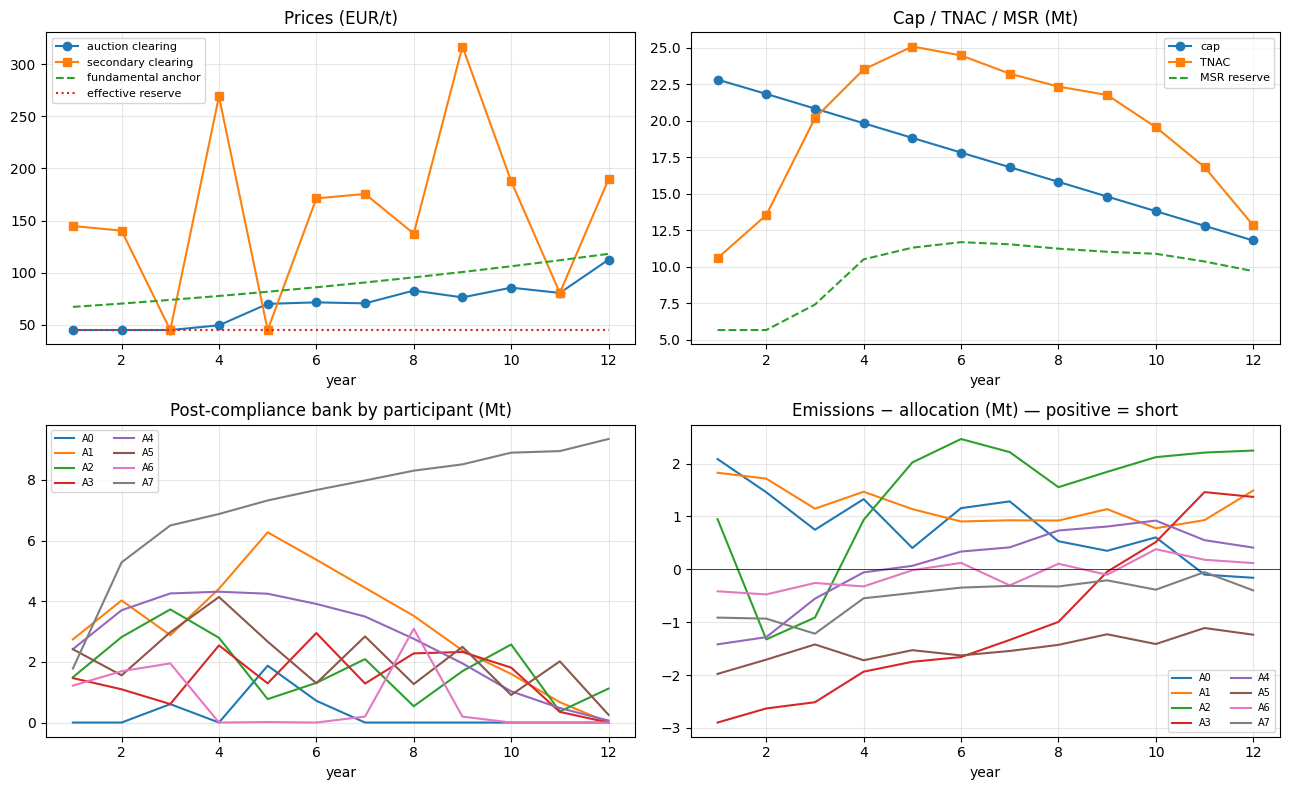

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ax = axes[0, 0]
ax.plot(market_summary_df["year"], market_summary_df["auction_clearing_eur"], "-o", label="auction clearing")
ax.plot(market_summary_df["year"], market_summary_df["secondary_clearing_eur"], "-s", label="secondary clearing")
ax.plot(market_summary_df["year"], market_summary_df["anchor_eur"], "--", label="fundamental anchor")
ax.plot(market_summary_df["year"], market_summary_df["reserve_eur"], ":", label="effective reserve")
ax.set_title("Prices (EUR/t)"); ax.set_xlabel("year"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(market_summary_df["year"], market_summary_df["cap_mt"], "-o", label="cap")
ax.plot(market_summary_df["year"], market_summary_df["tnac_mt"], "-s", label="TNAC")
ax.plot(market_summary_df["year"], market_summary_df["msr_reserve_mt"], "--", label="MSR reserve")
ax.set_title("Cap / TNAC / MSR (Mt)"); ax.set_xlabel("year"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
for i in range(N_TOTAL):
    sub = per_company_df[per_company_df["agent"] == i]
    ax.plot(sub["year"], sub["bank_post_compliance"], label=participant_label(i))
ax.set_title("Post-compliance bank by participant (Mt)"); ax.set_xlabel("year")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ax = axes[1, 1]
for i in range(N_TOTAL):
    sub = per_company_df[per_company_df["agent"] == i]
    ax.plot(sub["year"], sub["emissions_mt"] - sub["allocation_mt"], label=participant_label(i))
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Emissions − allocation (Mt) — positive = short")
ax.set_xlabel("year"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 14. Optional CSV export

Set `EXPORT_CSV = True` at the top of the notebook to dump every dataframe above into `EXPORT_DIR/`. Filenames are tagged with `INSPECT_YEAR` and `INSPECT_AGENT` so multiple invocations can coexist.


In [20]:
if EXPORT_CSV:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    tag = f"y{INSPECT_YEAR:02d}_a{INSPECT_AGENT:02d}_seed{SEED}"
    market_summary_df.to_csv(EXPORT_DIR / f"market_summary_{tag}.csv", index=False)
    per_company_df.to_csv(EXPORT_DIR / f"per_company_yearly_{tag}.csv", index=False)
    if "episode_agent_aggregate_df" in globals():
        episode_agent_aggregate_df.to_csv(EXPORT_DIR / f"episode_agent_aggregate_{tag}.csv")
    if "episode_reward_channel_sums_df" in globals() and not episode_reward_channel_sums_df.empty:
        episode_reward_channel_sums_df.to_csv(EXPORT_DIR / f"episode_reward_channel_sums_{tag}.csv")
    bidding_df.to_csv(EXPORT_DIR / f"bidding_year{INSPECT_YEAR:02d}.csv", index=False)
    secondary_df.to_csv(EXPORT_DIR / f"secondary_year{INSPECT_YEAR:02d}.csv", index=False)
    compliance_df.to_csv(EXPORT_DIR / f"compliance_year{INSPECT_YEAR:02d}.csv", index=False)
    investment_df.to_csv(EXPORT_DIR / f"investment_year{INSPECT_YEAR:02d}.csv", index=False)
    budget_df.to_csv(EXPORT_DIR / f"budget_year{INSPECT_YEAR:02d}.csv", index=False)
    if not reward_channels_df.empty:
        reward_channels_df.to_csv(EXPORT_DIR / f"reward_channels_year{INSPECT_YEAR:02d}.csv", index=False)
    if not per_agent_diag_df.empty:
        per_agent_diag_df.to_csv(EXPORT_DIR / f"per_agent_diag_year{INSPECT_YEAR:02d}.csv", index=False)
    walk_df.to_csv(EXPORT_DIR / f"agent{INSPECT_AGENT:02d}_walkthrough.csv", index=False)
    mix_history_df.to_csv(EXPORT_DIR / f"agent{INSPECT_AGENT:02d}_mix_history.csv", index=False)
    print(f"Wrote CSV exports to {EXPORT_DIR}")
else:
    print("EXPORT_CSV is False - set it to True at the top of the notebook to dump CSVs.")


EXPORT_CSV is False - set it to True at the top of the notebook to dump CSVs.


## 15. Raw `year_log` access

Every dataframe above is derived from `year_logs[INSPECT_YEAR - 1]`. The raw dict is kept around for ad-hoc deep dives — print its keys here, and pull whatever else you need (e.g. `opponent_snapshots`, `terminal_*_values`, `rewards_base`, `rewards_shaping`, etc.).


In [16]:
print(f"year_log keys (year {INSPECT_YEAR}):")
display(pd.DataFrame({"key": sorted(year_log.keys())}))

# Example ad-hoc pull:
# rewards_base    = year_log["rewards_base"]
# rewards_shaping = year_log["rewards_shaping"]
# opponent_snap   = year_log["opponent_snapshots"]


year_log keys (year 12):


,key
0,_year_1based
1,allocations
2,anchor_t
3,auction_stats
4,auction_volume
...,...
81,treasury_drawn
82,treasury_reserves
83,unsold_rollover_in
84,unsold_rollover_out


## 16. Per-year credit & compliance diagnostics

For the selected episode, surface year-level diagnostics recorded in `year_logs`:

- Carry-forward debt at year start vs end.
- Coverage gap (`max(0, need - alloc)`) before secondary trading.
- Treasury balance and outstanding emergency loan.
- Auction concentration (HHI) and secondary-market liquidity counts.

The cell below reads directly from this notebook's rollout logs and skips columns that are absent in older log schemas.


In [17]:
# Section 16 - expanded per-year diagnostics for this notebook's focal episode.
# Uses `year_logs` from the rollout above; no external run-log dataframe required.
import pandas as pd


def _list_value(log, key, idx, default=np.nan):
    values = log.get(key)
    if values is None or idx >= len(values):
        return default
    value = values[idx]
    return default if value is None else value


if not year_logs:
    print("[s16] year_logs not available - run the rollout cells first.")
else:
    market_rows = []
    for log in year_logs:
        stats = log.get("auction_stats", {}) or {}
        market_rows.append({
            "year": int(log.get("_year_1based", len(market_rows) + 1)),
            "auction_hhi": stats.get("hhi", np.nan),
            "auction_max_agent_share": stats.get("max_agent_share_actual", np.nan),
            "auction_total_demand": stats.get("total_demand", np.nan),
            "auction_unsold": stats.get("unsold", np.nan),
            "auction_failed": stats.get("auction_failed", np.nan),
            "auction_defaults": stats.get("defaults", 0),
            "secondary_n_buyers_executed": log.get("secondary_n_buyers_executed", np.nan),
            "secondary_n_sellers_executed": log.get("secondary_n_sellers_executed", np.nan),
            "common_emission_shock": log.get("common_emission_shock", np.nan),
            "fundamental_anchor": log.get("anchor_t", np.nan),
        })
    print("Auction & secondary-market panel:")
    display(pd.DataFrame(market_rows).round(3))

    rows = []
    for log in year_logs:
        year = int(log.get("_year_1based", len(rows) + 1))
        for i in range(N_TOTAL):
            rows.append({
                "year": year,
                "agent": i,
                "label": participant_label(i),
                "kind": participant_kind(i),
                "carry_forward_start": float(_list_value(log, "old_carry_forward", i, 0.0)),
                "carry_forward_end": float(_list_value(log, "new_carry_forward", i, np.nan)),
                "coverage_gap": float(_list_value(log, "coverage_gaps", i, np.nan)),
                "effective_penalty_rate": float(_list_value(log, "effective_penalty_rates", i, np.nan)),
                "treasury_reserve": float(_list_value(log, "treasury_reserves", i, np.nan)),
                "loan_outstanding": float(_list_value(log, "loan_outstanding", i, np.nan)),
            })
    pa_df = pd.DataFrame(rows)
    metric_cols = [c for c in pa_df.columns if c not in {"year", "agent", "label", "kind"}]
    if pa_df[metric_cols].notna().any().any():
        print("\nPer-agent compliance & credit state by year:")
        display(pa_df.round(3))
    else:
        print("[s16] Per-agent credit/compliance columns are missing in this log schema.")


Auction & secondary-market panel:


,year,auction_hhi,auction_max_agent_share,auction_total_demand,auction_unsold,auction_failed,auction_defaults,secondary_n_buyers_executed,secondary_n_sellers_executed,common_emission_shock,fundamental_anchor
0,1,"1,502.6710",0.2240,26.4340,0.0000,False,0,2,2,0.0650,67.2000
1,2,"1,483.2790",0.2250,23.0050,0.0000,False,0,2,2,0.1160,70.3960
2,3,"1,449.1370",0.2270,20.5700,0.0000,False,0,1,1,-0.0620,73.9130
3,4,"1,623.4080",0.2770,17.7230,0.0000,False,0,1,3,0.0300,77.6860
4,5,"1,863.1890",0.2970,17.4870,0.0000,False,0,2,2,0.0290,81.7230
5,6,"1,887.7460",0.2880,16.0540,0.0000,False,0,1,1,-0.0450,86.0320
6,7,"1,857.9870",0.2810,15.5230,0.0000,False,0,1,1,0.0670,90.6210
7,8,"1,827.7310",0.2510,15.3560,0.0000,False,0,1,1,-0.0940,95.4990
8,9,"1,794.0970",0.2720,15.3960,0.0000,False,0,1,1,-0.0680,100.6740
9,10,"1,944.0620",0.3000,15.0400,0.0000,False,0,1,1,-0.0220,106.1550



Per-agent compliance & credit state by year:


,year,agent,label,kind,carry_forward_start,carry_forward_end,coverage_gap,effective_penalty_rate,treasury_reserve,loan_outstanding
0,1,0,A0,learning,0.0000,0.1870,1.9910,138.7500,478.9210,0.0000
1,1,1,A1,learning,0.0000,0.0000,1.6790,138.7500,488.6470,0.0000
2,1,2,A2,learning,0.0000,0.0000,0.6550,138.7500,454.3480,0.0000
3,1,3,A3,learning,0.0000,0.0000,0.0000,138.7500,470.8920,0.0000
4,1,4,A4,learning,0.0000,0.0000,0.0000,138.7500,442.7710,0.0000
...,...,...,...,...,...,...,...,...,...,...
91,12,3,A3,learning,0.0000,1.0200,2.5030,167.0340,"1,253.7490",0.0000
92,12,4,A4,learning,0.0000,0.0000,0.5260,167.0340,"1,115.1060",0.0000
93,12,5,A5,learning,0.0000,0.0000,0.0000,167.0340,"1,105.1510",0.0000
94,12,6,A6,learning,0.3660,0.4840,0.5430,167.0340,"1,044.0900",0.0000
